In [100]:
import numpy as np
from pprint import pprint

from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import (
    SGDClassifier , RidgeClassifier , LogisticRegression
)
from sklearn.metrics import (
    log_loss,
    ConfusionMatrixDisplay,
    precision_score , recall_score , classification_report,
    precision_recall_curve , roc_curve , roc_auc_score
)

from sklearn.model_selection import (
    cross_validate,
    RandomizedSearchCV                                 
)

from scipy.stats import loguniform

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns


In [32]:
# global settings
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
mpl.rc('figure',figsize=(8,6))

# Ignore all warnings (convergence .. ) by sklearn
def warn(*args, ** kwargs):
    pass
import warnings
warnings.warn = warn

In [33]:
from sklearn.datasets import fetch_openml
x_pd , y_pd = fetch_openml('mnist_784' , version=1 , return_X_y=True)

In [34]:
x = x_pd.to_numpy()
y = y_pd.to_numpy()

### Handwritten Digit Classification

#### Introduction to the Problem
Image classification ML ka ek bohot popular use case hai. Is lecture mein hamara goal hai ek model banana jo hath se likhe hue numbers (0-9) ko pehchan sake. Iske liye hum **Logistic Regression** use karne wale hain. 

Lekin wait, iske naam mein "Regression" hai, toh ye classification kaise kar raha hai? Darasal, history mein iska invention regression ke math se inspire ho kar hua tha, par iska output hamesha 0 se 1 ke beech ek *probability* hota hai. Isliye isko broadly classification (categories batane) ke liye hi use kiya jata hai.

#### The Data: MNIST Dataset
ML model ko sikhane ke liye thousands of images aur unke correct labels (answers) chahiye hote hain. Khud se itni images likhna aur label karna "Daunting task" (bohot mushkil kaam) hai. Isliye hum **MNIST** dataset use karte hain. Ye ML ki duniya ka "Hello World" hai, jisme hazaaron pre-labeled handwritten digits hote hain.

**Data ko Math mein kaise dekhein?**
Computer photos nahi dekhta, wo sirf numbers ka matrix dekhta hai. MNIST ki har ek image grayscale hoti hai aur uska size 28x28 pixels hota hai. 
* Total pixels = $28 \times 28 = 784$.
* Model ko data dene ke liye hum is 2D grid ko ek lambi 1D array mein flatten kar dete hain. 
* Toh mathematically, hamara ek single input feature vector ($x$) ek 784-dimensional column vector hota hai: $x \in \mathbb{R}^{784}$.

#### Binary Classification: Zero vs. Non-Zero
Directly 10 digits (0 se 9) classify karne ki jagah, hum approach ko simple rakhte hain aur ek **Binary Classifier** banate hain. Hum model se sirf ek sawal puchenge: *"Kya ye photo '0' ki hai, ya kisi aur number ki?"*
* Class 1 ($y = 1$): Image '0' ki hai.
* Class 0 ($y = 0$): Image koi aur digit hai (1, 2, 3... 9).

#### Mathematical Formulation (Basic to Advance)

**Step 1: The Linear Combination**
Model ka kaam hai har ek pixel ke importance ko samajhna. Kuch pixels (jaise center wale) shayad hamesha dark hon, par edges wale pixels hi decide karenge ki circle ('0') ban raha hai ya line ('1'). Model in 784 pixels ke liye alag-alag weights ($w$) learn karta hai. 

Hum in sabka ek weighted sum nikalte hain aur ek bias ($b$) add karte hain. Equation aisi dikhti hai:
$$z = w_1x_1 + w_2x_2 + \dots + w_{784}x_{784} + b$$

Agar hum isko matrices/vectors ki bhasha mein likhein (jo Python/Numpy mein use hota hai):
$$z = \mathbf{w}^T\mathbf{x} + b$$
*(Yahan $\mathbf{w}$ weights ka vector hai aur $\mathbf{x}$ pixels ka vector hai)*

**Step 2: The Sigmoid Function (Applying Probability)**
Ab jo ye $z$ nikal kar aaya hai, iski value kuch bhi ho sakti hai (kabhi -1000 toh kabhi +5000). Lekin classification ke liye hume percentage ya probability chahiye (yaani 0 se 1 ke beech ka number). 

Isko scale karne ke liye hum $z$ ko **Sigmoid function** ($\sigma$) ke andar daal dete hain:
$$P(y=1 | \mathbf{x}) = \sigma(z) = \frac{1}{1 + e^{-z}}$$

* Agar $\mathbf{w}^T\mathbf{x} + b$ ki value badi aur positive hai, toh equation ka result $1$ ke paas chala jayega (Matlab model keh raha hai "Bhai pakka ye '0' hai").
* Agar value negative hai, toh result $0$ ke paas chala jayega (Model keh raha hai "Ye '0' nahi hai").

Is ek step ke saath, hamara simple linear equation ek powerful classifier ban jata hai jo images padh sakta hai!

---

### Data Pre-Processing for Logistic Regression

#### 1. The Rule: Scaling to [0, 1] Range
Jaise lecture mein bataya gaya hai, Perceptron algorithm thoda dheeth hota hai — usme scaling optional hai. Lekin Logistic Regression, jo probability nikalne ke liye **Sigmoid function** ka use karta hai, uske liye data ko $0$ aur $1$ ke beech scale karna *compulsory* hai. 

MNIST dataset mein image ka har pixel ek number hota hai jo $0$ (Black) se $255$ (White) ke beech hota hai. Hum in sabko $255$ se divide kar dete hain taaki saari values $0.0$ aur $1.0$ ke range mein aa jayein.

#### 2. Consequences of Not Scaling (The Math Behind It)
Lecture ne pucha hai ki "Contemplate the consequences" (Socho agar hum scale nahi karenge toh kya hoga?). Isko mathematically samajhte hain.

Hume pata hai ki Sigmoid ka input ek weighted sum hota hai:
$$z = \mathbf{w}^T\mathbf{x} + b$$

Agar humare input pixels ($\mathbf{x}$) ki value bohot badi hai (jaise 200 ya 255), toh weights se multiply hone ke baad overall $z$ ki value ya toh bohot badi positive (jaise $+1000$) aayegi ya bohot badi negative (jaise $-1000$) aayegi.

Ab Sigmoid ka formula dekho:
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

*   **Agar $z = +1000$:** $e^{-1000}$ lagbhag $0$ ho jayega. Equation ban jayegi $\frac{1}{1+0} = 1$.
*   **Agar $z = -1000$:** $e^{1000}$ bohot bada ho jayega. Equation ban jayegi $\frac{1}{\text{infinity}} = 0$.

Jab input bada hota hai, toh Sigmoid curve ekdum **flat** ho jata hai. Agar curve flat ho gaya, toh derivative (slope/dhalan) $0$ ho jata hai. Isko Machine Learning mein **Vanishing Gradient Problem** kehte hain. Tumhara algorithm andha ho jata hai, usko samajh nahi aata ki weights ko kis direction mein update karein, aur **model ki learning wahi stop ho jati hai.**

#### 3. Why NOT Mean Centering? (Preserving Sparsity)
Ek aur bohot common scaling technique hoti hai 'Mean Centering' (data ka average nikal kar har value se minus karna: $x_i - \mu$). Lekin lecture mein isse explicitly mana kiya gaya hai. Kyu?

Images aur text data mein, **'0' ki ek original identity hoti hai.** MNIST mein '0' ka matlab hai ki wahan koi ink nahi hai (pure black pixel). Aisi matrices jisme bohot saare zeros hote hain, unhe **Sparse Matrices** kehte hain. 

Agar tum Mean Centering karoge, toh saare $0$ wale pixels change ho kar negative numbers (jaise $-0.5$) ban jayenge. Isse 2 nuksaan honge:
1. Data ki original visual meaning khatam ho jayegi (Empty space ab empty nahi rahi).
2. Sparse matrix "Dense" ban jayegi, jisse memory (RAM) zyada use hogi aur matrix multiplication slow ho jayega.
Isliye hum sirf $255$ se divide karte hain, jisse jo $0$ hai, wo operation ke baad bhi $0$ hi rahe ($0 / 255 = 0$).

#### 4. Skipping the Pipeline
`sklearn.pipeline.Pipeline` ka use hum tab karte hain jab hume 3-4 pre-processing steps (jaise pehle missing values fill karo $\rightarrow$ fir mean center karo $\rightarrow$ fir PCA lagao) ko ek line mein chain karna ho. 

Kyunki yahan hamara operation sirf ek basic sa step hai:
`X_train = X_train / 255.0`
Isliye pura Pipeline likhna unnecessary aur overkill hai. Hum isko directly numpy operation ke through code mein apply kar sakte hain.

---

In [35]:
scaler = MinMaxScaler()
X = scaler.fit_transform(x)
print(f"Mean (X) : {X.mean():.3f}")
print(f"Standard Deviation (X) : {X.std():.3f}")
print(f"Max Val : {X.max()}")
print(f"Min Val : {X.min()}")

Mean (X) : 0.131
Standard Deviation (X) : 0.308
Max Val : 1.0
Min Val : 0.0


In [36]:
target_names = np.unique(y)
print(f"Number of samples : {X.shape[0]} , dtype : {X.dtype}")
print(f"Number of Features : {X.shape[1]}")
print(f"Number of clases : {len(target_names)} , dtype : {target_names.dtype}")
print(f"Labels : {target_names}")

Number of samples : 70000 , dtype : float64
Number of Features : 784
Number of clases : 10 , dtype : object
Labels : ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


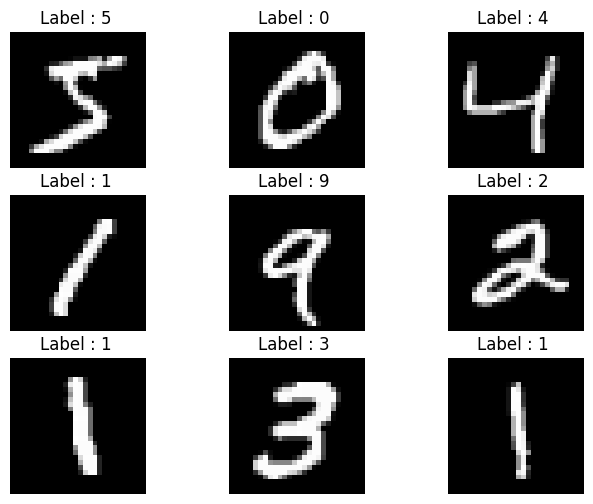

In [45]:
num_images = 9 # Choose a square number
factor = np.int16(np.sqrt(num_images))
fig,ax = plt.subplots(nrows=factor,ncols=factor,figsize=(8,6))
idx_offset = 0 # take "num_images" starting from the index "idx_offset"
for i in range(factor):
    index = idx_offset+i*(factor)
    for j in range(factor):
        ax[i, j].imshow(X[ index+j].reshape(28, 28) , cmap='gray')
        ax[i, j].set_title( 'Label : {0} '.format(str(y[ index+j] ) ) )
        ax[i, j].set_axis_off()

#### Data Spliting

In [46]:
x_train, x_test, y_train, y_test = X[ :60000], X[60000 : ] , y[ : 60000], y[ 60000 : ]

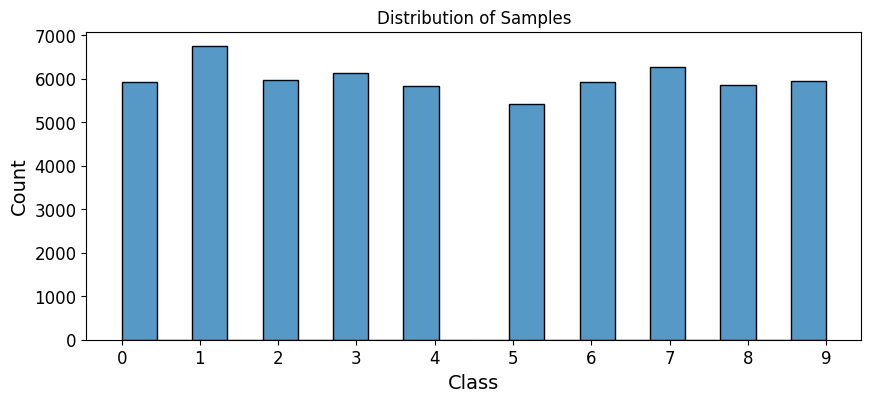

In [47]:
plt.figure(figsize=(10,4))
sns.histplot(data=np.int8(y_train),binwidth=0.45,bins=11)
plt.xticks(ticks=[0,1,2,3,4,5,6,7,8,9],labels=[0,1,2,3,4,5,6,7,8,9])
plt.xlabel('Class')
plt.title('Distribution of Samples')
plt.show()

#### Binary-Classification : 0-Detector

In [48]:
y_train_0 = np.zeros(len(y_train))
y_test_0 = np.zeros(len(y_test))

index_0 = np.where(y_train=='0')
y_train_0[index_0] = 1

index_0 = np.where(y_test=='0')
y_test_0[index_0] = 1

In [49]:
print(y_train)
print(y_train_0)

['5' '0' '4' ... '5' '6' '8']
[0. 1. 0. ... 0. 0. 0.]


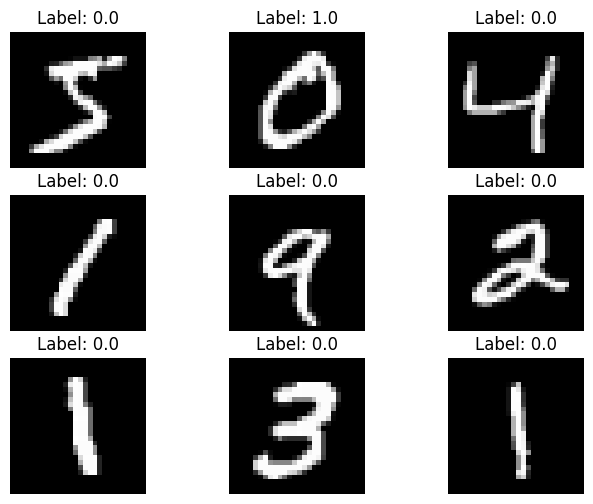

In [53]:
num_images = 9 # Choose a square number
factor = np.int8(np.sqrt(num_images))
fig,ax = plt.subplots(nrows=factor,ncols=factor,figsize=(8,6))
idx_offset = 0 # take "num_images" starting from the index "idx_offset"
for i in range(factor) :
    index = idx_offset+i*(factor)
    for j in range(factor) :
        ax[i,j].imshow(X[index+j].reshape(28, 28) , cmap='gray' )
        ax[i, j].set_title('Label: {0}'.format(str(y_train_0[ index+j] ) ) )
        ax[i, j].set_axis_off()

In [56]:
num_pos = len(np.where(y_train_0 == 0)[0])
num_neg = len(np.where(y_train_0 == 0)[0])
print(num_pos , num_neg)

54077 54077


In [63]:
base_clf = DummyClassifier()
base_clf.fit(x_train , y_train_0)
print(base_clf.score(x_train , y_train_0))

0.9012833333333333


### To use SGDClassifie as LogisticClassifier , use loss='log_loss'

In [66]:
bin_sgd_clf = SGDClassifier(
    loss='log_loss',
    penalty='l2',
    alpha=0,
    max_iter=1,
    eta0=0.01,
    warm_start=True,
    learning_rate='constant',
    random_state=1729
)

Loss = []
iteration = 100
for i in range(iteration):
    bin_sgd_clf.fit(x_train , y_train_0)
    y_pred = bin_sgd_clf.predict(x_train)
    Loss.append( log_loss(y_train_0 , y_pred) )

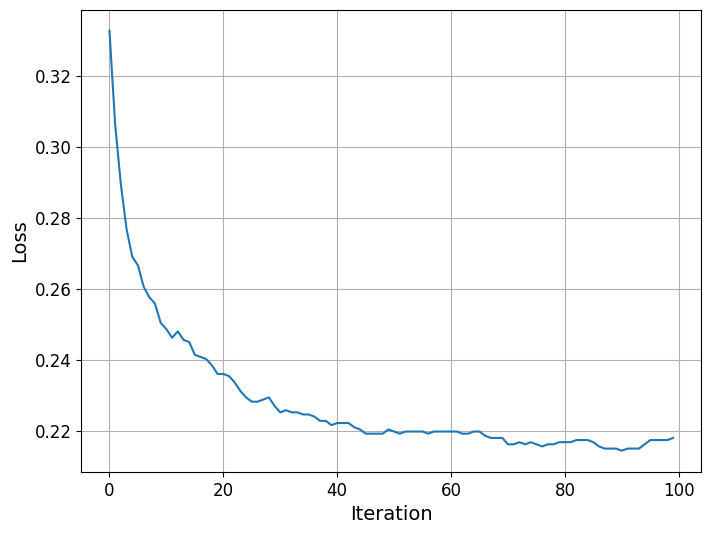

In [67]:
plt.figure()
plt.plot(np.arange(iteration),Loss)
plt.grid(True)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()

In [68]:
print('Training accuracy: %.2f'%bin_sgd_clf. score(x_train, y_train_0))
print('Testing accuracy: %.2f'%bin_sgd_clf.score(x_test, y_test_0) )

Training accuracy: 0.99
Testing accuracy: 0.99


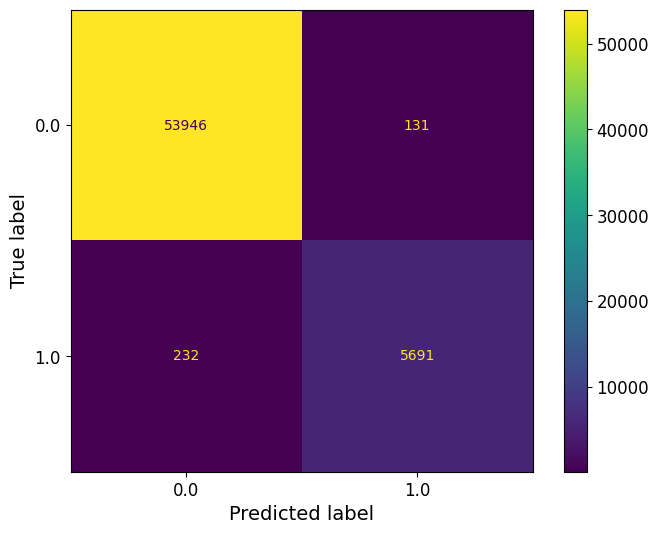

In [80]:
y_hat_train_0 = bin_sgd_clf.predict(x_train)
cm_matrix = ConfusionMatrixDisplay.from_predictions(y_train_0 , y_hat_train_0 , values_format=".5g")
plt.show()

In [78]:
print(classification_report(y_train_0 , y_hat_train_0))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     54077
         1.0       0.98      0.96      0.97      5923

    accuracy                           0.99     60000
   macro avg       0.99      0.98      0.98     60000
weighted avg       0.99      0.99      0.99     60000



### Cross Validation

In [85]:
estimator = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=0,
    warm_start=True,
    max_iter=1,
    eta0=0.01,
    learning_rate="constant",
    random_state=1729
)

cv_bin_clf = cross_validate(
    estimator , x_train, y_train_0,
    cv=5,
    scoring = ["precision","recall","f1"],
    return_train_score=True,
    return_estimator=True
)

pprint(cv_bin_clf)

{'estimator': [SGDClassifier(alpha=0, learning_rate='constant', loss='log_loss', max_iter=1,
              random_state=1729, warm_start=True),
               SGDClassifier(alpha=0, learning_rate='constant', loss='log_loss', max_iter=1,
              random_state=1729, warm_start=True),
               SGDClassifier(alpha=0, learning_rate='constant', loss='log_loss', max_iter=1,
              random_state=1729, warm_start=True),
               SGDClassifier(alpha=0, learning_rate='constant', loss='log_loss', max_iter=1,
              random_state=1729, warm_start=True),
               SGDClassifier(alpha=0, learning_rate='constant', loss='log_loss', max_iter=1,
              random_state=1729, warm_start=True)],
 'fit_time': array([0.23801947, 0.23606181, 0.27102089, 0.31434917, 0.2431066 ]),
 'score_time': array([0.01399899, 0.01200271, 0.01299548, 0.01899934, 0.01399493]),
 'test_f1': array([0.94883721, 0.94961571, 0.95872743, 0.95019489, 0.95577501]),
 'test_precision': array([0.9500

In [89]:
weights = bin_sgd_clf.coef_
bias = bin_sgd_clf.intercept_

print('Dimension of Weights w: {0}'.format(weights.shape))
print('Bias : {0}'.format(bias))

Dimension of Weights w: (1, 784)
Bias : [-4.89282893]


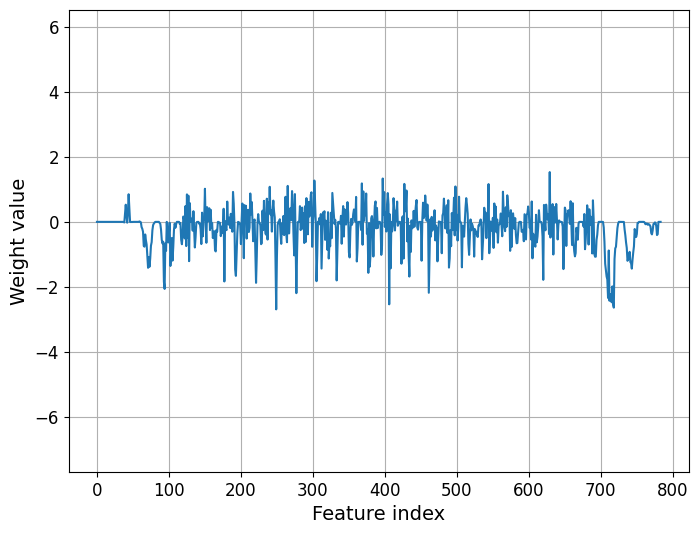

In [90]:
plt.figure()
plt.plot(np.arange(0,784),weights[0,:])
plt.xlabel('Feature index')
plt.ylabel('Weight value')
plt.ylim((np.min(weights)-5, np.max(weights)+5))
plt.grid()

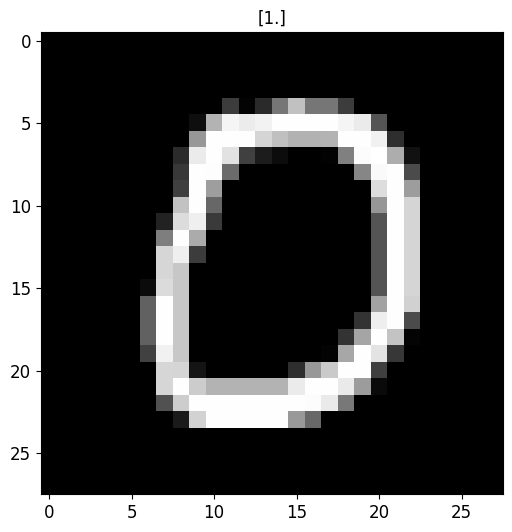

In [91]:
index = 10 # try some other index
plt.imshow(x_test[index,:].reshape(28,28),cmap='gray')
pred = bin_sgd_clf.predict(x_test[index].reshape(1,-1))
plt.title(str(pred))
plt.show()

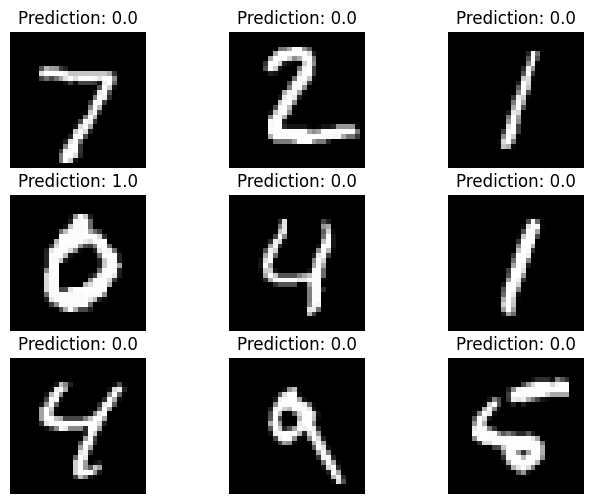

In [96]:
y_hat_test_0 = bin_sgd_clf.predict(x_test)
num_images = 9 # Choose a square number
factor = np.int8(np.sqrt(num_images))
fig,ax = plt.subplots(nrows=factor,ncols=factor,figsize=(8,6))
idx_offset = 0 # display "num_images" starting from idx_offset
for i in range(factor):
    index = idx_offset+i*(factor)
    for j in range(factor):
        ax[i, j] .imshow(x_test[ index+j].reshape(28, 28) , cmap='gray' ) # we should not use x_train_with_dummy
        ax[i,j].set_title('Prediction: {0}'.format(str(y_hat_test_0[ index+j]) ) )
        ax[i, j] .set_axis_off()

#### Hyperparameter Tuning

In [98]:
lr_grid = loguniform(1e-2 , 1e-1)
print(lr_grid.rvs(3,random_state=42))

[0.02368864 0.0892718  0.05395031]


In [99]:
# repeating for convenience
estimator= SGDClassifier(
    loss='log',
    penalty='12',
    max_iter=1,
    warm_start=True,
    eta0=0.01,
    alpha=0,
    learning_rate='constant',
    random_state=1729
)

In [108]:
# repeating for convenience
estimator= SGDClassifier (
    loss='log_loss',
    penalty='l2',
    max_iter=1,
    warm_start=True,
    eta0=0.01,
    alpha=0,
    learning_rate='constant',
    random_state=1729
)

In [109]:

scores = RandomizedSearchCV(
    estimator,
    param_distributions={'eta0' : lr_grid},
    cv=5,
    scoring=['precision', 'recall', 'f1' ],
    n_iter=5,
    refit='f1'
)


In [110]:
scores.fit(x_train , y_train_0)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SGDClassifier...rm_start=True)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.",{'eta0': <scipy.stats....001CAF3F46510>}
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","['precision', 'recall', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fo

In [111]:
pprint(scores.cv_results_)

{'mean_fit_time': array([0.64814925, 0.74487858, 0.2379775 , 0.23100595, 0.22607269]),
 'mean_score_time': array([0.05713367, 0.05591912, 0.01240726, 0.01223068, 0.01219091]),
 'mean_test_f1': array([0.95352305, 0.95342663, 0.94171496, 0.9420019 , 0.94562536]),
 'mean_test_precision': array([0.96055589, 0.9607114 , 0.93642323, 0.93730269, 0.94377776]),
 'mean_test_recall': array([0.94698954, 0.94665184, 0.94851123, 0.94817368, 0.94851052]),
 'param_eta0': masked_array(data=[0.02532949509836844, 0.024689457635499373,
                   0.0876812260202579, 0.08494078233529465,
                   0.06717589919101945],
             mask=[False, False, False, False, False],
       fill_value=1e+20),
 'params': [{'eta0': np.float64(0.02532949509836844)},
            {'eta0': np.float64(0.024689457635499373)},
            {'eta0': np.float64(0.0876812260202579)},
            {'eta0': np.float64(0.08494078233529465)},
            {'eta0': np.float64(0.06717589919101945)}],
 'rank_test_f1': arr

In [113]:
best_bin_clf = scores.best_estimator_

In [114]:

y_hat_train_best_0 = best_bin_clf.predict(x_train)

In [115]:

print(classification_report(y_train_0, y_hat_train_best_0))

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     54077
         1.0       0.99      0.89      0.94      5923

    accuracy                           0.99     60000
   macro avg       0.99      0.94      0.96     60000
weighted avg       0.99      0.99      0.99     60000



### Classification Report

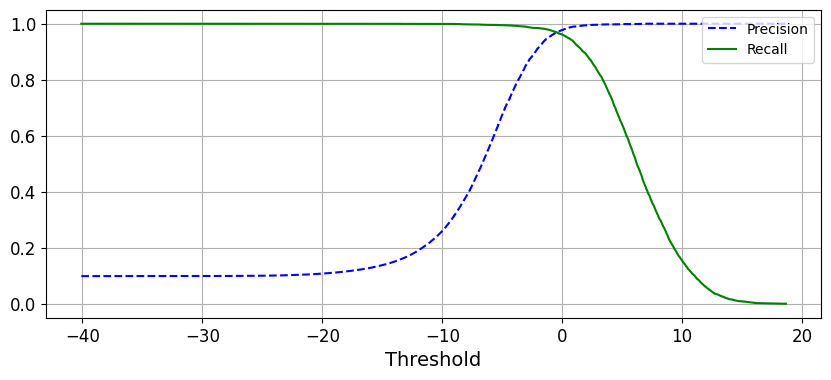

In [117]:
y_scores = bin_sgd_clf.decision_function(x_train)
precisions, recalls, thresholds = precision_recall_curve(y_train_0, y_scores)
plt.figure(figsize=(10,4))
plt.plot(thresholds, precisions[ :-1], "b--", label="Precision")
plt.plot(thresholds, recalls[ :-1], "g-", label="Recall")
plt.xlabel('Threshold')
plt.grid(True)
plt.legend(loc='upper right')
plt.show()

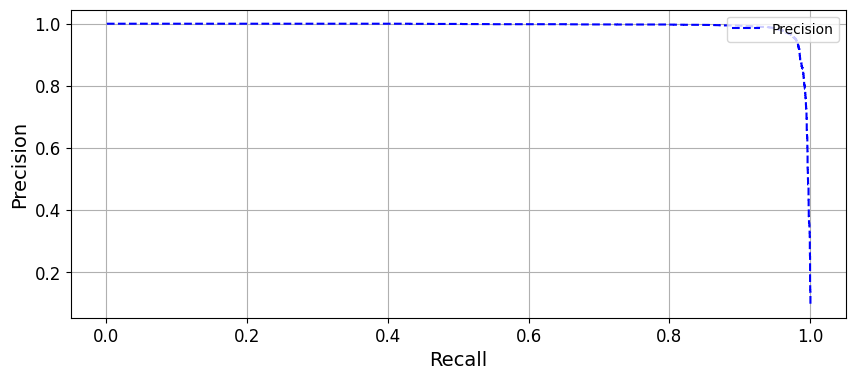

In [118]:
plt.figure(figsize=(10,4))
plt.plot( recalls[ :-1],precisions[ :-1],"b--", label="Precision")
plt.ylabel('Precision')
plt.xlabel('Recall')
plt.grid(True)
plt.legend(loc='upper right')
plt.show()

#### ROC curve

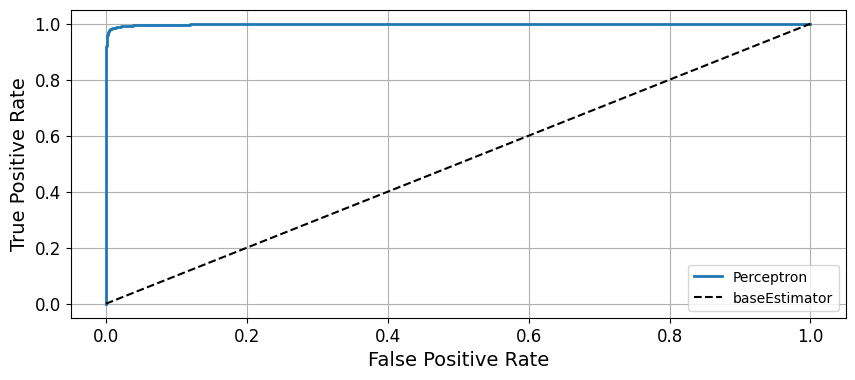

In [119]:
fpr, tpr, thresholds = roc_curve(y_train_0, y_scores)
plt.figure(figsize=(10,4))
plt.plot(fpr, tpr, linewidth=2,label='Perceptron')
plt.plot([0, 1], [0, 1], 'k--',label='baseEstimator')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.legend()
plt.show()

In [120]:
auc = roc_auc_score(y_train_0,y_scores)
print('AUC: %.3f' % auc)

AUC: 0.998
